# 02 - Model Development and Training

## 1. Library Imports

In [11]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn

# HuggingFace Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed as hf_set_seed
)
from transformers import set_seed as hf_set_seed
from datasets import Dataset
import evaluate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress tracking
from tqdm.auto import tqdm

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [12]:
# Check System Information 
print("System Information:")
print(f"PyTorch version: {torch.__version__}")


System Information:
PyTorch version: 2.9.1+cpu


## 2. Load Configuration

In [50]:
# Load parameters from params.yaml
def load_params(path=r'C:\Users\Darjay\Desktop\ML&MLOps-Training_GovTech\ML-lifecycle-project\machine-learning-lifecycle-darjaysonam\params.yaml'):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)

params = load_params()

# Extract training parameters
train_params = params['train']
data_params = params['data']

print("Training Configuration:")
print("-" * 60)
for key, value in train_params.items():
    print(f"{key:20s}: {value}")

print("\nData Configuration:")
print("-" * 60)
for key, value in data_params.items():
    print(f"{key:20s}: {value}")

Training Configuration:
------------------------------------------------------------
model_name          : distilbert-base-uncased
batch_size          : 8
epochs              : 1
learning_rate       : 2e-5
max_length          : 96
validation_split    : 0.2
seed                : 42

Data Configuration:
------------------------------------------------------------
raw_dir             : data/raw
train_file          : imdb_train.parquet
test_file           : imdb_test.parquet


## 3. Set Random Seeds for Reproducibility

In [ ]:
seed = train_params.get('seed', 42)
set_seed(seed)

print(f"✓ Random seed set to: {seed}")

## 4. Load and Prepare Data

In [15]:
from pathlib import Path
import pandas as pd

print("Loading data...")

raw_dir = Path("../data/raw")

train_path = raw_dir / data_params['train_file']
test_path  = raw_dir / data_params['test_file']

train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

print(f"✓ Training samples: {len(train_df):,}")
print(f"✓ Test samples: {len(test_df):,}")

Loading data...
✓ Training samples: 25,000
✓ Test samples: 25,000


In [16]:
# Create train/validation split
val_frac = train_params['validation_split']
print(f"\nCreating {val_frac:.0%} validation split...")

# Shuffle and split
train_df = train_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
n_val = int(len(train_df) * val_frac)
val_df = train_df.iloc[:n_val]
tr_df = train_df.iloc[n_val:]

print(f"✓ Training: {len(tr_df):,} samples")
print(f"✓ Validation: {len(val_df):,} samples")

# Check label distribution
print("\nLabel distribution:")
print(f"Training - Negative: {(tr_df['label']==0).sum():,}, Positive: {(tr_df['label']==1).sum():,}")
print(f"Validation - Negative: {(val_df['label']==0).sum():,}, Positive: {(val_df['label']==1).sum():,}")


Creating 20% validation split...
✓ Training: 20,000 samples
✓ Validation: 5,000 samples

Label distribution:
Training - Negative: 9,985, Positive: 10,015
Validation - Negative: 2,515, Positive: 2,485


In [17]:
# Convert to HuggingFace Dataset format
ds_train = Dataset.from_pandas(tr_df[['text', 'label']], preserve_index=False)
ds_val = Dataset.from_pandas(val_df[['text', 'label']], preserve_index=False)

print("\n✓ Converted to HuggingFace Dataset format")
print(f"  Train dataset: {ds_train}")
print(f"  Val dataset: {ds_val}")


✓ Converted to HuggingFace Dataset format
  Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 20000
})
  Val dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


In [ ]:
print(train_params)

## 5. Load Tokenizer and Tokenize Data

In [18]:
# Load tokenizer
model_name = train_params['model_name']
print(f"Loading tokenizer: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"✓ Tokenizer loaded")
print(f"  Vocabulary size: {len(tokenizer):,}")
print(f"  Max model length: {tokenizer.model_max_length:,}")

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014931B8BFD0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: bcd0f996-0525-4d15-93a6-f66142b0b688)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


Loading tokenizer: distilbert-base-uncased


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014932250E90>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 88be85e9-e2c8-4287-b433-4a6d241be632)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014932252110>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 87b6ce5b-7dba-4a2d-b67f-f3378dc5927d)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-u

✓ Tokenizer loaded
  Vocabulary size: 30,522
  Max model length: 512


In [52]:
# Test tokenization on sample text
sample_text = "This movie was absolutely fantastic! I loved every minute of it."
print("\nTokenization Example:")
print("-" * 60)
print(f"Original text: {sample_text}")

# Tokenize
encoded = tokenizer(sample_text, truncation=True, padding='max_length', max_length=32)

print(f"\nToken IDs: {encoded['input_ids'][:20]}...")
print(f"Attention mask: {encoded['attention_mask'][:20]}...")

# Decode back
decoded = tokenizer.decode(encoded['input_ids'])
print(f"\nDecoded: {decoded}")

# Show tokens
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][:20])
print(f"\nTokens: {tokens}")


Tokenization Example:
------------------------------------------------------------
Original text: This movie was absolutely fantastic! I loved every minute of it.

Token IDs: [101, 2023, 3185, 2001, 7078, 10392, 999, 1045, 3866, 2296, 3371, 1997, 2009, 1012, 102, 0, 0, 0, 0, 0]...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]...

Decoded: [CLS] this movie was absolutely fantastic! i loved every minute of it. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

Tokens: ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '!', 'i', 'loved', 'every', 'minute', 'of', 'it', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [20]:
# Define tokenization function
max_length = train_params['max_length']

def tokenize_function(batch):
    """Tokenize a batch of texts"""
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=max_length
    )

print(f"\nTokenizing dataset (max_length={max_length})...")
print("This may take a few minutes...")

# Tokenize datasets
ds_train_tokenized = ds_train.map(tokenize_function, batched=True)
ds_val_tokenized = ds_val.map(tokenize_function, batched=True)

print("✓ Tokenization complete")


Tokenizing dataset (max_length=96)...
This may take a few minutes...


Map: 100%|████████████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 2565.00 examples/s]

✓ Tokenization complete


In [56]:
# Inspecting tokenized training and validation data sets {features: ['text', 'label', 'input_ids', 'attention_mask']}

print(f"\nTokenized Train Dataset i.e input_ids & attention_mask:")

print(ds_train_tokenized[:1])


Tokenized Train Dataset i.e input_ids & attention_mask:
{'label': tensor([1]), 'input_ids': tensor([[  101,  1045, 11780,  2023,  3185,  2750,  2049,  5186,  2659,  5790,
          1010,  2138,  1045,  2359,  2000,  2156,  2129,  1996,  3626,  9020,
          2000,  2019, 21499,  1996,  3739,  1997,  3674,  8484,  1012,  2004,
          1037,  3043,  1997,  2755,  1010,  2027,  2134,  1005,  1056,  1011,
          2012,  2560,  1010,  2061,  2049,  3849,  1012,  2070, 12081,  3311,
          3013,  2738, 18856, 18163,  6588,  2046,  1996,  3185,  1011,  2008,
          1005,  1055,  2009,  1010,  2023,  2003,  2054,  1996,  3484,  1997,
          7193,  2228,  1012,  2174,  1010,  1996,  4474,  3310,  2012,  1996,
          2203,  1010,  1998,  6854,  2059,  1010,  2043,  2763,  2087,  1997,
          1996,  7193,  2031,  2525,  3030,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [22]:
# Set format for PyTorch
columns = ['input_ids', 'attention_mask', 'label']
ds_train_tokenized.set_format(type='torch', columns=columns)
ds_val_tokenized.set_format(type='torch', columns=columns)

print("✓ Dataset format set to PyTorch")
print(f"  Train columns: {ds_train_tokenized.column_names}")
print(f"  Sample shape: {ds_train_tokenized[0]['input_ids'].shape}")

✓ Dataset format set to PyTorch
  Train columns: ['text', 'label', 'input_ids', 'attention_mask']
  Sample shape: torch.Size([96])


## 6. Load Pre-trained Model

In [57]:
# Load Pre-trained DistilBERT Model

model_name = train_params['model_name']

print(f"Loading pre-trained model: {model_name}")
print("This may take a minute...")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification (Positive / Negative)
)

print("✓ Model loaded successfully")

print("-" * 60) # Showing Model Information

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014942F6E490>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 730a0c16-7e6d-4c54-aa32-dd22dc7d2d5e)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Loading pre-trained model: distilbert-base-uncased
This may take a minute...


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014942F37F10>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 4957336a-7be8-4969-8c70-f3a8d7cfa033)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014942F6DF90>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: ecca9137-ea26-4fd2-89f1-14d1e0327f18)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.jso

✓ Model loaded successfully
------------------------------------------------------------
Total parameters: 66,955,010
Trainable parameters: 66,955,010


In [58]:
# Model architecture
print("\nModel Architecture:")
print("-" * 60)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nParameter Count:")
print("-" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1e6:.0f} MB (float32)")


Model Architecture:
------------------------------------------------------------
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine

## 7. Define Evaluation Metrics

In [25]:
# Load metrics
metric_accuracy = evaluate.load('accuracy')
metric_f1 = evaluate.load('f1')

def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = metric_accuracy.compute(predictions=predictions, references=labels)['accuracy']
    f1 = metric_f1.compute(predictions=predictions, references=labels, average='binary')['f1']
    
    return {
        'accuracy': accuracy,
        'f1': f1
    }

print("✓ Metrics defined: accuracy, f1")

Using the latest cached version of the module from D:\hf_cache\modules\evaluate_modules\metrics\evaluate-metric--accuracy\f887c0aab52c2d38e1f8a215681126379eca617f96c447638f751434e8e65b14 (last modified on Sun Feb 22 18:37:51 2026) since it couldn't be found locally at evaluate-metric--accuracy, or remotely on the Hugging Face Hub.
Using the latest cached version of the module from D:\hf_cache\modules\evaluate_modules\metrics\evaluate-metric--f1\34c46321f42186df33a6260966e34a368f14868d9cc2ba47d142112e2800d233 (last modified on Sun Feb 22 18:37:55 2026) since it couldn't be found locally at evaluate-metric--f1, or remotely on the Hugging Face Hub.


✓ Metrics defined: accuracy, f1


## 8. Configure Training Arguments

In [60]:
# All model checkpoints and logs will be saved here
output_dir = Path("models/trained/distilbert_sentiment")
output_dir.mkdir(parents=True, exist_ok=True)

# Define training configuration
training_args = TrainingArguments(

    # Where HuggingFace saves checkpoints
    output_dir=str(output_dir / "_hf_runs"),

    # Core training hyperparameters
    num_train_epochs=train_params["epochs"],
    per_device_train_batch_size=train_params["batch_size"],
    per_device_eval_batch_size=train_params["batch_size"],
    learning_rate=float(train_params["learning_rate"]),

    # Evaluation & model selection
    evaluation_strategy="epoch",        # Evaluate after each epoch
    save_strategy="epoch",              # Save checkpoint after each epoch
    load_best_model_at_end=True,        # Restore best model automatically
    metric_for_best_model="f1",         # Select best model using F1 score

    # Regularization & optimization
    warmup_ratio=0.1,                   # 10% warmup for LR scheduler
    weight_decay=0.01,                  # L2 regularization

    # Logging
    logging_dir=str(output_dir / "_logs"),
    logging_steps=50,
    report_to=[],                       # Disable WandB/other loggers

    # Miscellaneous
    seed=seed,
    fp16=torch.cuda.is_available(),     # Mixed precision if GPU available
)

# Display training summary

total_steps = (
    len(ds_train_tokenized)
    // training_args.per_device_train_batch_size
    * training_args.num_train_epochs
)

print("\nTraining Configuration")
print("-" * 60)
print(f"Output directory        : {training_args.output_dir}")
print(f"Epochs                  : {training_args.num_train_epochs}")
print(f"Batch size              : {training_args.per_device_train_batch_size}")
print(f"Learning rate           : {training_args.learning_rate}")
print(f"Warmup ratio            : {training_args.warmup_ratio}")
print(f"Weight decay            : {training_args.weight_decay}")
print(f"Mixed precision (FP16)  : {training_args.fp16}")
print(f"Estimated training steps: ~{total_steps:,}")


Training Configuration
------------------------------------------------------------
Output directory        : models\trained\distilbert_sentiment\_hf_runs
Epochs                  : 1
Batch size              : 8
Learning rate           : 2e-05
Warmup ratio            : 0.1
Weight decay            : 0.01
Mixed precision (FP16)  : False
Estimated training steps: ~2,500


## 9. Create Trainer

In [32]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train_tokenized,
    eval_dataset=ds_val_tokenized,
    compute_metrics=compute_metrics,
)

print("✓ Trainer initialized")
print(f"  Model: {model_name}")
print(f"  Train samples: {len(ds_train_tokenized):,}")
print(f"  Val samples: {len(ds_val_tokenized):,}")

✓ Trainer initialized
  Model: distilbert-base-uncased
  Train samples: 20,000
  Val samples: 5,000


## 10. Train the Model

In [33]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start training
print("\n" + "=" * 80)
print("STARTING TRAINING")
print("=" * 80)
print(f"\nDevice: {device}")
print(f"Expected time: {'20-30 min (GPU)' if torch.cuda.is_available() else '3-4 hours (CPU)'}")
print("\nTraining progress will be displayed below...\n")

# Train
train_result = trainer.train()

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)


STARTING TRAINING

Device: cpu
Expected time: 3-4 hours (CPU)

Training progress will be displayed below...



C:\Users\Darjay\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.331700,0.356413,0.850400,0.852057


C:\Users\Darjay\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



TRAINING COMPLETE


In [34]:
# Print training metrics
print("\nTraining Metrics:")
print("=" * 60)
for key, value in train_result.metrics.items():
    print(f"{key:30s}: {value:.4f}")


Training Metrics:
train_runtime                 : 12805.4733
train_samples_per_second      : 1.5620
train_steps_per_second        : 0.1950
total_flos                    : 496752744960000.0000
train_loss                    : 0.4122
epoch                         : 1.0000


## 11. Evaluate on Validation Set

In [35]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_metrics = trainer.evaluate()

print("\nValidation Metrics:")
print("=" * 60)
print(f"Accuracy: {val_metrics['eval_accuracy']:.4f} ({val_metrics['eval_accuracy']*100:.2f}%)")
print(f"F1 Score: {val_metrics['eval_f1']:.4f}")
print(f"Loss: {val_metrics['eval_loss']:.4f}")

Evaluating on validation set...


C:\Users\Darjay\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Validation Metrics:
Accuracy: 0.8504 (85.04%)
F1 Score: 0.8521
Loss: 0.3564


## 12. Visualize Training Progress

In [36]:
# Extract training history from logs
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

print(f"Training steps logged: {len(train_logs)}")
print(f"Evaluation epochs logged: {len(eval_logs)}")

Training steps logged: 50
Evaluation epochs logged: 2


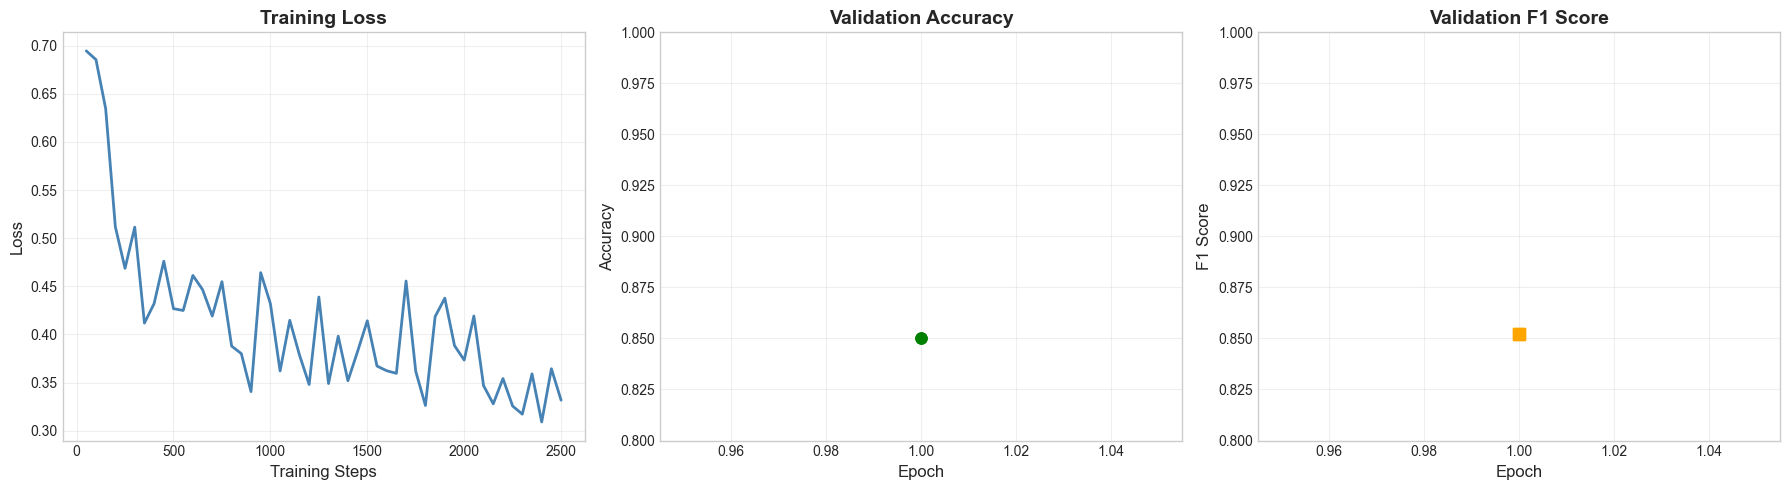

✓ Saved: reports/training_curves.png


In [38]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
if train_logs:
    steps = [log['step'] for log in train_logs if 'loss' in log]
    losses = [log['loss'] for log in train_logs if 'loss' in log]
    axes[0].plot(steps, losses, linewidth=2, color='steelblue')
    axes[0].set_xlabel('Training Steps', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

# Validation accuracy
if eval_logs:
    epochs = [log['epoch'] for log in eval_logs]
    accuracies = [log['eval_accuracy'] for log in eval_logs]
    axes[1].plot(epochs, accuracies, marker='o', linewidth=2, markersize=8, color='green')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0.8, 1.0])
    axes[1].grid(True, alpha=0.3)

# Validation F1
if eval_logs:
    f1_scores = [log['eval_f1'] for log in eval_logs]
    axes[2].plot(epochs, f1_scores, marker='s', linewidth=2, markersize=8, color='orange')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].set_title('Validation F1 Score', fontsize=14, fontweight='bold')
    axes[2].set_ylim([0.8, 1.0])
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: reports/training_curves.png")

## 13. Save the Model

In [40]:
# Save model and tokenizer
print("Saving model and tokenizer...")

model_save_path = Path('../models/trained/distilbert_sentiment')
model_save_path.mkdir(parents=True, exist_ok=True)

# Save model
trainer.model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✓ Model saved to: {model_save_path}")

# List saved files
print("\nSaved files:")
for file in sorted(model_save_path.iterdir()):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"  - {file.name:30s} ({size_mb:6.1f} MB)")

Saving model and tokenizer...
✓ Model saved to: ..\models\trained\distilbert_sentiment

Saved files:
  - config.json                    (   0.0 MB)
  - model.safetensors              ( 255.4 MB)
  - special_tokens_map.json        (   0.0 MB)
  - tokenizer.json                 (   0.7 MB)
  - tokenizer_config.json          (   0.0 MB)
  - vocab.txt                      (   0.2 MB)


## 14. Test Predictions

In [41]:
# Function to predict sentiment
def predict_sentiment(text, model, tokenizer, device):
    """Predict sentiment for a single text"""
    # Tokenize
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )
    
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1)
    
    # Extract results
    label = 'positive' if prediction.item() == 1 else 'negative'
    confidence = probs[0][prediction].item()
    prob_negative = probs[0][0].item()
    prob_positive = probs[0][1].item()
    
    return {
        'label': label,
        'confidence': confidence,
        'prob_negative': prob_negative,
        'prob_positive': prob_positive
    }

print("✓ Prediction function defined")

✓ Prediction function defined


In [49]:
# Test on sample reviews
test_reviews = [
    "The movies had many unwanted scenes, that was little surprise for viewers as parent.",
    "It had some meaningful insights, however, the ending part was little confusing without any substance.",
    "It was okay, nothing special to make review about.",
    "Some scene could be improved in the movie, however, overall I would give average rating!.",
    "I nearly dosed off, my time was wasted by such movie.",
    "I would like to recommend this movie to mid age person, as it gives lot of wisdom and knowledge."
]

print("Test Predictions:")
print("-" * 80)

for i, review in enumerate(test_reviews, 1):
    result = predict_sentiment(review, model, tokenizer, device)
    
    print(f"\n[{i}] {review}")
    print(f"    Prediction: {result['label'].upper()}")
    print(f"    Confidence: {result['confidence']:.2%}")
    print(f"    P(negative): {result['prob_negative']:.2%}, P(positive): {result['prob_positive']:.2%}")

Test Predictions:
--------------------------------------------------------------------------------

[1] The movies had many unwanted scenes, that was little surprise for viewers as parent.
    Prediction: NEGATIVE
    Confidence: 88.06%
    P(negative): 88.06%, P(positive): 11.94%

[2] It had some meaningful insights, however, the ending part was little confusing without any substance.
    Prediction: NEGATIVE
    Confidence: 73.58%
    P(negative): 73.58%, P(positive): 26.42%

[3] It was okay, nothing special to make review about.
    Prediction: NEGATIVE
    Confidence: 92.11%
    P(negative): 92.11%, P(positive): 7.89%

[4] Some scene could be improved in the movie, however, overall I would give average rating!.
    Prediction: NEGATIVE
    Confidence: 78.21%
    P(negative): 78.21%, P(positive): 21.79%

[5] I nearly dosed off, my time was wasted by such movie.
    Prediction: NEGATIVE
    Confidence: 98.59%
    P(negative): 98.59%, P(positive): 1.41%

[6] I would like to recommend 

In [48]:
# Test on validation samples
print("\n" + "=" * 80)
print("Validation Sample Predictions:")
print("=" * 80)

# Get 5 random samples
sample_indices = np.random.choice(len(val_df), 5, replace=False)

for idx in sample_indices:
    text = val_df.iloc[idx]['text']
    true_label = 'positive' if val_df.iloc[idx]['label'] == 1 else 'negative'
    
    result = predict_sentiment(text, model, tokenizer, device)
    correct = '✓' if result['label'] == true_label else '✗'
    
    print(f"\nText: {text[:100]}...")
    print(f"True label: {true_label}")
    print(f"Predicted: {result['label']} ({result['confidence']:.2%}) {correct}")


Validation Sample Predictions:

Text: Every now and then a film maker brings to life a unique group of people and lets you inside to see t...
True label: positive
Predicted: positive (98.39%) ✓

Text: Oh my goodness. This was a real big mess that just couldn't help itself. Jeffrey (Jon Heder) is a 29...
True label: negative
Predicted: negative (98.45%) ✓

Text: Magicians is a wonderful ride from start to finish, thanks in large part to the magic that is genera...
True label: positive
Predicted: positive (98.71%) ✓

Text: I don't remember when I first heard about this movie, but I rented it about six years ago, and it st...
True label: positive
Predicted: positive (97.36%) ✓

Text: I just got back from the film and I'm completely appalled. This movie is an absolute mockery to all ...
True label: negative
Predicted: negative (98.37%) ✓


## 15. Model Summary and Next Steps

In [64]:
# Final summary
print("MODEL DEVELOPMENT SUMMARY")
print("-" * 80)

print("\n1. Model Configuration:")
print(f"   Architecture: {model_name}")
print(f"   Parameters: {total_params:,}")
print(f"   Device: {device}")

print("\n2. Training Configuration:")
print(f"   Epochs: {train_params['epochs']}")
print(f"   Batch size: {train_params['batch_size']}")
print(f"   Learning rate: {train_params['learning_rate']}")
print(f"   Max length: {train_params['max_length']}")

print("\n3. Dataset:")
print(f"   Training samples: {len(tr_df):,}")
print(f"   Validation samples: {len(val_df):,}")
print(f"   Test samples: {len(test_df):,}")

print("\n4. Performance:")
print(f"   Validation Accuracy: {val_metrics['eval_accuracy']:.4f} ({val_metrics['eval_accuracy']*100:.2f}%)")
print(f"   Validation F1 Score: {val_metrics['eval_f1']:.4f}")
print(f"   Validation Loss: {val_metrics['eval_loss']:.4f}")

MODEL DEVELOPMENT SUMMARY
--------------------------------------------------------------------------------

1. Model Configuration:
   Architecture: distilbert-base-uncased
   Parameters: 66,955,010
   Device: cpu

2. Training Configuration:
   Epochs: 1
   Batch size: 8
   Learning rate: 2e-5
   Max length: 96

3. Dataset:
   Training samples: 20,000
   Validation samples: 5,000
   Test samples: 25,000

4. Performance:
   Validation Accuracy: 0.8504 (85.04%)
   Validation F1 Score: 0.8521
   Validation Loss: 0.3564
